<a href="https://colab.research.google.com/github/tkg-create/FlyRank-ML-Track/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tkg-create/FlyRank-ML-Track/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Setup

Clone the repo, run the pipeline once, and load the data every section below reuses. `01` and `02` run here. `03` and `04`'s outputs are already committed and get loaded directly from JSON wherever a section needs them — no rerun required.

In [1]:
import os

REPO_URL = "https://github.com/tkg-create/FlyRank-ML-Track.git"
REPO_DIR = "FlyRank-ML-Track"

if not os.path.isdir(REPO_DIR):
    !git clone {REPO_URL}

os.chdir(REPO_DIR)
print("Working dir:", os.getcwd())
assert os.path.isfile("work/scripts/01_load_and_score.py"), "01_load_and_score.py not found — did the clone work?"

Cloning into 'FlyRank-ML-Track'...
remote: Enumerating objects: 459, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 459 (delta 75), reused 37 (delta 29), pack-reused 336 (from 2)
Receiving objects: 100% (459/459), 2.09 MiB | 7.71 MiB/s, done.
Resolving deltas: 100% (261/261), done.
Working dir: /content/FlyRank-ML-Track


In [2]:
import subprocess
import sys
import os
from getpass import getpass

os.environ["HF_TOKEN"] = getpass("Paste your Hugging Face READ token: ")

process = subprocess.Popen(
    [sys.executable, "-u", "work/scripts/run_all.py"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)
for line in process.stdout:
    print(line, end="")
process.wait()
assert process.returncode == 0, f"run_all.py failed with exit code {process.returncode}"

Paste your Hugging Face READ token: ··········

▶ Step 1/2 — Load — warehouse features, baseline rule, out-of-fold RF scoring, calibration
Loading and building features from the warehouse...
  [1/6] Querying label (impressions first half vs second half)...
        -> 151,981 rows
  [2/6] Querying full-month position/click signal (baseline rule)...
        -> 175,304 rows
  [3/6] Querying first-half-only features (model training data)...
        -> 150,675 rows
  [4/6] Querying leakage-safe position trend (week 1 vs week 2)...
        -> 119,176 rows
  [5/6] Querying client map (grouping key only, never a feature)...
        -> 331,437 rows
  [6/6] Merging into model_df...
model_df: (150675, 16), base rate: 0.438
Running 5-fold GroupKFold OOF scoring (random_state=42)...
  Fold 1/5: fitting on 120,583 rows, scoring 30,092...
  Fold 1/5: done
  Fold 2/5: fitting on 120,589 rows, scoring 30,086...
  Fold 2/5: done
  Fold 3/5: fitting on 120,351 rows, scoring 30,324...
  Fold 3/5: done
  F

In [3]:
import pandas as pd
import json

model_df = pd.read_csv("work/data/processed/w07_scored_population.csv")
queue_df = pd.read_csv("work/data/processed/w07_ranked_queue.csv")

print(f"model_df: {len(model_df):,} rows")
print(f"queue_df: {len(queue_df):,} rows")

model_df: 150,675 rows
queue_df: 150,675 rows


## 1. Question

*The research question and the decision it supports.*

Organizations that manage content across many sites face the same mismatch: the portfolio of pages is far larger than the capacity to review it by hand. Editorial attention is scarce, so it has to be spent on the pages where it matters most. Given a fixed review capacity, which declining pages should be reviewed first, and what should a reviewer actually do with each one?

This work tests whether a model-based ranking answers that question better than a hand-built rule, for a portfolio of several dozen client sites and hundreds of thousands of pages. Review capacity is set at 50 pages per month (`REVIEW_CAPACITY_K`, defined below), an assumed budget, chosen because it's also where a model-informed ranking held its advantage over the rule most consistently under grouped cross-validation, winning in 5 of 5 folds (see Methodology and Results).

What follows validates that approach against one month of historical data under honest cross-validation. It doesn't deliver a tool that scores new pages every month on its own yet, see Limitations for what that would still take.

In [4]:
"""
Assumed monthly review capacity — chosen because grouped cross-validation found
this is where a model-informed ranking's edge over the rule is most consistent (5/5 folds),
not just where it looks best on average. See Methodology and Results.
"""
REVIEW_CAPACITY_K = 50

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Tables:** Each row represents one page, on one date, for one client. The table is `fact_content_daily_performance`, filtered to the `month=2026-03` partition of the internship warehouse. That month was chosen deliberately. Earlier months are missing analytics history for many clients, and later months overlap a separate 90-day table's window in a way that risks the label and features bleeding into each other. A month in the middle of the panel avoids both problems.

**Date windows:** The single month is split into two windows. The first half of the month versus the second half, March 1 to 15 against March 16 to 31, defines the decline label. Week 1 versus week 2 of the first half, March 1 to 8 against March 9 to 15, defines the position-trend feature. The feature window sits strictly before the label window, so no feature can see into the period it's predicting.

**Excluded, and why:** The raw first-half and second-half impression counts that the label is built from are excluded from every feature set. Adding one of them back in as a diagnostic pushed a model's ROC AUC from 0.564 to 0.991, which meant the model was reconstructing the label algebraically rather than learning anything real. A content-metadata table was excluded because it turned out to be a current-state snapshot rather than a point-in-time history. Joining it onto daily rows produced impossible negative day counts. Rows without a confirmed analytics coverage flag were excluded, since those rows measure "not tracked" rather than a genuine zero. A session-rate engagement signal was excluded as well, after earlier analysis found it confounded and pointing in the wrong direction, and has been left out of every model built since.

**Public-safe:** Every identifier used for joining or grouping is a hashed ID and is never used as a model feature. No client name, URL, or search query text appears anywhere in this pipeline's outputs.

In [5]:
print(f"Rows: {len(model_df):,}")
print(f"Unique clients: {model_df['client_hash_id'].nunique()}")
print(f"Base rate (share labeled declining): {model_df['is_declining_proxy'].mean():.3f}")
model_df[["avg_position_fh", "log_impressions_fh", "log_clicks_fh", "ctr_fh", "position_change", "has_position_trend"]].describe()

Rows: 150,675
Unique clients: 44
Base rate (share labeled declining): 0.438


,avg_position_fh,log_impressions_fh,log_clicks_fh,ctr_fh,position_change,has_position_trend
count,150675.000000,150675.000000,150675.000000,150675.000000,150675.000000,150675.000000
mean,16.546579,4.630053,0.526925,0.004285,0.618596,0.790947
std,18.215346,2.287959,0.901977,0.034230,9.208292,0.406633
min,0.040763,0.693147,0.000000,0.000000,-213.750000,0.000000
25%,5.186723,2.833213,0.000000,0.000000,-0.950392,1.000000
50%,8.756892,4.709530,0.000000,0.000000,0.000000,1.000000
75%,21.131311,6.410175,0.693147,0.002023,1.666203,1.000000
max,310.000000,11.992731,7.781556,1.000000,153.750000,1.000000


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Assumptions:** Pages need at least 10 impressions across the month to be trusted for position and click-through numbers; pages below that bar are excluded, not treated as zero. The decline label is a proxy, not proof of real decline, and captures a within-month direction rather than a causal or long-term trend. Validation is grouped by client, on the assumption that a model shouldn't be tested on a client whose other pages it trained on. That's a reasonable default, not the only option; alternatives weren't tested.

**Model and features:** A Random Forest with 300 trees, max depth 6, minimum 20 samples per leaf, trained on six features: average position, log impressions, log clicks, click-through rate, position change, and whether a position trend exists at all. A seventh candidate, a zero-click flag, was built but left out on purpose, since it only ever backed an earlier diagnostic. So the model sees click-through problems only indirectly, through CTR and click volume.

**Label:** A page is labeled declining by comparing search impressions in the first half of the month to the second half. The raw impression counts from either half are never allowed as features; adding one back in as a diagnostic pushed a model from barely above chance to near perfect, confirming it would have been reconstructing the label rather than learning anything real.

**Baseline:** A transparent rule with two parts: a page holding a top-10 position with zero clicks, and a page whose position got worse from week 1 to week 2. The zero-click flag counts for more when combined into a single score. Every input is knowable at the decision moment, so no model is required.

**Validation design:** Five-fold cross-validation grouped by client rather than by page, since a model trained on some of a client's pages and tested on others would leak that client's patterns across the split. All evaluation scores are out of fold.

**Cross-fold calibration:** Five separate models, one per fold, have their out-of-fold scores pooled into one column for ranking. That only works if all five models' scores mean the same thing. They didn't: one fold's model scored systematically higher without being more accurate, and a naive pooled ranking gave that fold 93 to 100 percent of the top of the queue at every depth checked, while the fold with the most real positives was almost entirely absent from it.

Two fixes were tried and rejected first. One shared probability curve across all folds couldn't tell which fold a row came from, so it couldn't apply opposite corrections to two folds that needed them. A separate curve per fold fixed that, but each was estimated from a limited sample and came out a different shape, so the same imbalance reappeared with a different fold in the lead.

The fix that held: convert each fold's scores to a percentile rank within that fold. Nothing gets estimated, so nothing can come out uneven between folds by chance.

**Queue ranking:** The queue was originally meant to rank by the model's score with a small nudge from the rule. Once calibration was in place, that combination was tested several ways, different nudge weights, rule-tier-first sorting, a percentile blend, and every version reintroduced the same fold imbalance calibration was meant to fix. The queue ranks on the calibrated score alone; the rule still sets every page's archetype and action, just not sort order.

**Leakage checks:** Four checks were run before trusting any result: that no feature's time window crosses into the label's window, that the label's eligibility filter doesn't encode the outcome, that no feature is a near-duplicate of the label, and a deliberate injection test confirming the validation setup actually catches a known-leaky column. All four passed.

In [6]:
import sys
sys.path.insert(0, "work/scripts")
from w07_pipeline_utils import FEATURE_COLS, RANDOM_STATE, N_FOLDS

print("Features:", FEATURE_COLS)
print(f"GroupKFold folds: {N_FOLDS}, grouped by client_hash_id")
print(f"Random Forest: n_estimators=300, max_depth=6, min_samples_leaf=20, random_state={RANDOM_STATE}")
print(f"Baseline rule: baseline_score = zero_clicks_at_position*2 + position_worsened")
print(f"Calibration: percentile rank within each fold (oof_rf_score_calibrated)")
print(f"Queue ranking: oof_rf_score_calibrated alone, no rule-based combination")

Features: ['avg_position_fh', 'log_impressions_fh', 'log_clicks_fh', 'ctr_fh', 'position_change', 'has_position_trend']
GroupKFold folds: 5, grouped by client_hash_id
Random Forest: n_estimators=300, max_depth=6, min_samples_leaf=20, random_state=42
Baseline rule: baseline_score = zero_clicks_at_position*2 + position_worsened
Calibration: percentile rank within each fold (oof_rf_score_calibrated)
Queue ranking: oof_rf_score_calibrated alone, no rule-based combination


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Precision at K, mean and standard deviation across the 5 held-out folds. The model's score is the calibrated version described in Methodology. Base rate, the share of pages actually labeled declining, is shown alongside it since a high score means little without knowing what a lucky guess would already get.

| K | baseline_rule | model (calibrated) | base rate |
|---|---|---|---|
| 20 | 0.490 ± 0.124 | 0.530 ± 0.057 | 0.438 |
| 50 | 0.420 ± 0.107 | 0.556 ± 0.065 | 0.438 |
| 100 | 0.412 ± 0.119 | 0.582 ± 0.075 | 0.438 |
| 200 | 0.433 ± 0.131 | 0.578 ± 0.056 | 0.438 |

At K=50, the depth this work is framed around, the model beats the rule in every fold: 0.66 vs 0.48, 0.58 vs 0.54, 0.50 vs 0.28, 0.52 vs 0.46, 0.52 vs 0.34. Five wins out of five, not an average hiding a mixed result.

At K=100 and K=200 the gap holds under a bootstrap check on the fold-level differences. The 95 percent interval sits at [0.082, 0.240] at K=100 and [0.045, 0.212] at K=200, both entirely above zero.

**Fold fairness.** However, there is a second, separate question. Does the ranking draw evenly from every fold, or does one fold's rows crowd out the rest regardless of which pages are actually declining? Before calibration, the answer was no. Pooling five independently trained models' raw scores gave one single fold 93 to 100 percent of the top of the queue at every depth checked, while the fold with the highest real base rate was almost entirely absent from it. After calibration, every fold contributes exactly 20 percent of the top of the queue at every depth checked, matching what 5 evenly sized folds should produce if none of them were being favored by an artifact of how the scores happened to be pooled.

In [7]:
import json

with open("work/outputs/capstone_precision_at_k.json") as f:
    precision = json.load(f)
with open("work/outputs/fold_representation_check.json") as f:
    fold_check = json.load(f)

print(f"base_rate: {precision['base_rate']:.3f}\n")

print(f"{'K':<6}{'baseline_rule':<20}{'model (calibrated)':<22}")
for k in ["20", "50", "100", "200"]:
    b = precision["summary_mean_std"][k]["baseline_rule"]
    m = precision["summary_mean_std"][k]["oof_rf_score_calibrated"]
    print(f"{k:<6}{b['mean']:.3f} +/- {b['std']:.3f}{'':<6}{m['mean']:.3f} +/- {m['std']:.3f}")

print("\nK=50, fold by fold:")
k50 = [r for r in precision["fold_level"] if r["k"] == 50]
wins = 0
for r in sorted(k50, key=lambda r: r["fold"]):
    won = r["oof_rf_score_calibrated"] > r["baseline_rule"]
    wins += won
    print(f"  fold {r['fold']}: baseline={r['baseline_rule']:.2f}  model={r['oof_rf_score_calibrated']:.2f}  {'model wins' if won else 'baseline wins'}")
print(f"model wins {wins}/5 folds")

print("\nBootstrap 95% CI, model - baseline:")
for k in ["50", "100", "200"]:
    ci = precision["bootstrap_ci"][k]["calibrated_vs_baseline"]
    print(f"  K={k}: mean_diff={ci['mean_diff']:.3f}  CI=[{ci['ci_low']:.3f}, {ci['ci_high']:.3f}]")

print("\nFold representation of the top-K queue (share per fold, calibrated score):")
for k in ["20", "50", "100", "200"]:
    shares = fold_check["top_k_representation"]["oof_rf_score_calibrated"][k]["share_by_fold"]
    print(f"  K={k}: " + ", ".join(f"fold{f}={s:.0%}" for f, s in shares.items()))

base_rate: 0.438

K     baseline_rule       model (calibrated)    
20    0.490 +/- 0.124      0.530 +/- 0.057
50    0.420 +/- 0.107      0.556 +/- 0.065
100   0.412 +/- 0.119      0.580 +/- 0.074
200   0.433 +/- 0.131      0.577 +/- 0.056

K=50, fold by fold:
  fold 1: baseline=0.48  model=0.66  model wins
  fold 2: baseline=0.54  model=0.58  model wins
  fold 3: baseline=0.28  model=0.50  model wins
  fold 4: baseline=0.46  model=0.52  model wins
  fold 5: baseline=0.34  model=0.52  model wins
model wins 5/5 folds

Bootstrap 95% CI, model - baseline:
  K=50: mean_diff=0.136  CI=[0.072, 0.196]
  K=100: mean_diff=0.168  CI=[0.082, 0.236]
  K=200: mean_diff=0.144  CI=[0.045, 0.211]

Fold representation of the top-K queue (share per fold, calibrated score):
  K=20: fold1=20%, fold2=20%, fold3=20%, fold4=20%, fold5=20%
  K=50: fold1=20%, fold2=20%, fold3=20%, fold4=20%, fold5=20%
  K=100: fold1=20%, fold2=20%, fold3=20%, fold4=20%, fold5=20%
  K=200: fold1=20%, fold2=20%, fold3=20%, fold4=

## 5. Limitations

*What this work cannot claim.*

**About a fifth of the population has no rule signal at all.** 31,499 of 150,675 pages have no valid week 1 versus week 2 position data and are treated as non-worsening by default. Most of those, 87.8 percent, get no rule-based flag at all and depend entirely on the model to be noticed. Found during later validation, not the original build.

**One month, not a trend.** Everything here comes from a single month. The label is a within-month comparison, first half against second half. Nothing has been checked against a different month, season, or longer window.

**The review capacity is assumed.** K=50 was chosen because it's where the model's advantage over the rule held up most consistently in validation, not a real reviewer capacity that was specified.

**Equal fold representation is enforced by calibration, not something the data actually shows.** The folds have real base rates from 0.33 to 0.56, so a fold with more true positives arguably deserves more than an equal share of the top of the ranking. A version that weighted contribution by base rate was tested and made the imbalance worse, so equal representation was kept as the safer tradeoff.

**The calibrated score ranks pages correctly, but no longer means "probability of decline."** It's a percentile position within a fold's own scores, not an estimated probability. It can sort a queue but can't support anything needing the actual magnitude, like an expected-value calculation.

**Calibration only has meaning within a fold that exists, so this isn't a live monthly tool yet.** A new page scored next month wouldn't belong to any cross-validation fold. Retraining on a past month would work close to as-is, but scoring new pages going forward would need a persisted model, a calibration method that generalizes beyond an existing fold, and a retraining and drift-monitoring cadence, none of which exists yet.

**The calibration method was chosen by comparing several options against the same five folds.** That's a mild form of selection bias beyond what cross-validation alone protects against. The reported numbers are for the method chosen this way, not one fixed in advance and checked once.

**Two gaps in what the model can see.** A direct zero-click feature was built but excluded, so click-through problems are only seen indirectly through CTR and click volume. There's also no validated signal for pages that get clicks but bounce immediately; the one candidate tested was confounded with impression volume.

**A tier called "confidence" was actually backwards.** A check found low-confidence rows had a higher real decline rate than high-confidence rows in every archetype. Renamed to `coverage`, since it measures data volume, not reliability.

**The K=50 win comes mostly from one archetype, largely because of population size, not signal quality.** `zero_clicks_and_worsened` pages score highest on average of any archetype, 0.749, and reach the same maximum scores as any other group. But `position_worsened_only` has roughly five times as many pages and a wider score spread, so it supplies most of the top 50 even though it isn't the highest-scoring group on average. Feature importances rule out one explanation: `position_change` is one of the least influential features in the model, so this isn't the model simply favoring a feature it weights heavily. The win over the rule at K=50 is real, but currently concentrated in visibility-loss declines more than click-through-loss ones.

In [8]:
with open("work/outputs/sentinel_fill_check.json") as f:
    sentinel = json.load(f)

print(f"No trend data: {sentinel['no_trend_count']:,} / {sentinel['population_size']:,} rows ({sentinel['no_trend_share']:.1%})")
print("\nOf those, share by resulting baseline_score:")
for score, share in sentinel["baseline_score_breakdown"].items():
    print(f"  {score}: {share:.3f}")
print(f"\nShare with no rule-based signal at all (baseline_score == 0): {sentinel['no_signal_share']:.1%}")
print("\nFold base rates (for the equal-representation tradeoff above):")
for fold, rate in sentinel["fold_base_rates"].items():
    print(f"  fold {fold}: {rate}")

No trend data: 31,499 / 150,675 rows (20.9%)

Of those, share by resulting baseline_score:
  0: 0.878
  2: 0.122

Share with no rule-based signal at all (baseline_score == 0): 87.8%

Fold base rates (for the equal-representation tradeoff above):
  fold 1: 0.436
  fold 2: 0.478
  fold 3: 0.391
  fold 4: 0.56
  fold 5: 0.328


In [9]:
with open("work/outputs/queue_diagnostics.json") as f:
    diagnostics = json.load(f)

print("Real decline rate by archetype and coverage tier:")
for key, stats in diagnostics["coverage_outcome"].items():
    archetype, coverage = key.split("|")
    print(f"  {archetype:<28} {coverage:<6} mean={stats['mean']:.3f}  count={stats['count']}")

Real decline rate by archetype and coverage tier:
  model_only_catch             high   mean=0.449  count=1884
  model_only_catch             low    mean=0.536  count=5402
  no_flag                      high   mean=0.331  count=44227
  no_flag                      low    mean=0.579  count=21343
  position_worsened_only       high   mean=0.436  count=48348
  position_worsened_only       low    mean=0.469  count=4405
  zero_clicks_and_worsened     high   mean=0.529  count=7876
  zero_clicks_and_worsened     low    mean=0.606  count=2733
  zero_clicks_only             high   mean=0.421  count=9646
  zero_clicks_only             low    mean=0.472  count=4811


In [10]:
with open("work/outputs/w07_metrics.json") as f:
    metrics = json.load(f)
print("Mean score by rule archetype:")
print(metrics["rule_agreement_mean_scores"])

print("\nArchetype counts at increasing K:")
for k, counts in diagnostics["k_sweep"].items():
    print(f"  K={k}: {counts}")

with open("work/outputs/feature_importance.json") as f:
    importance = json.load(f)
print("\nMean feature importance across 5 folds:")
print(importance["mean_importance"])

print("\nScore distribution by archetype:")
for archetype, stats in diagnostics["score_distribution_by_archetype"].items():
    print(f"  {archetype}: {stats}")

Mean score by rule archetype:
{'no_flag': 0.386, 'position_worsened_only': 0.492, 'zero_clicks_and_worsened': 0.749, 'zero_clicks_only': 0.642}

Archetype counts at increasing K:
  K=100: {'model_only_catch': 40, 'position_worsened_only': 59, 'zero_clicks_and_worsened': 1}
  K=1000: {'model_only_catch': 355, 'position_worsened_only': 548, 'zero_clicks_and_worsened': 59, 'zero_clicks_only': 38}
  K=50: {'model_only_catch': 20, 'position_worsened_only': 30}
  K=500: {'model_only_catch': 167, 'position_worsened_only': 309, 'zero_clicks_and_worsened': 16, 'zero_clicks_only': 8}

Mean feature importance across 5 folds:
{'avg_position_fh': 0.22083928009858617, 'ctr_fh': 0.2079240634167198, 'has_position_trend': 0.09420757622786384, 'log_clicks_fh': 0.09067244976213763, 'log_impressions_fh': 0.2567148356703763, 'position_change': 0.12964179482431631}

Score distribution by archetype:
  model_only_catch: {'max': 1.0, 'mean': 0.942, 'p50': 0.946, 'p95': 0.993, 'p99': 0.999}
  no_flag: {'max': 0

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The top 50 pages, ranked by the calibrated model score, form this cycle's review list. Each row carries the recommended action from Methodology's archetype rules: refresh content, overhaul title and meta, both together, flag for manual review, or monitor.

The remaining pages in the scored population are triaged the same way, just not reviewed this cycle. The split below shows how many fall into an action tier versus monitor-only.

For guidance on how a reviewer should actually work through this queue, see the deployed paper's Recommendations section.

In [11]:
top_50 = queue_df.head(50)[["content_hash_id", "archetype", "action", "oof_rf_score"]]
print(f"Top 50 review queue ({len(top_50)} pages):")
top_50

Top 50 review queue (50 pages):


,content_hash_id,archetype,action,oof_rf_score
0,content_334bcb2761d0f9c7,model_only_catch,Flag for manual review,1.000000
1,content_39457d17e716086c,position_worsened_only,Refresh content,1.000000
2,content_f98166a30c643b7c,position_worsened_only,Refresh content,1.000000
3,content_3e56218fa52d24b8,position_worsened_only,Refresh content,1.000000
4,content_c63784807a77c864,position_worsened_only,Refresh content,1.000000
5,content_7b37f22d2086ca56,position_worsened_only,Refresh content,0.999967
6,content_9bcfb1e373c01b7a,position_worsened_only,Refresh content,0.999967
7,content_83a700e06cf9e676,model_only_catch,Flag for manual review,0.999967
8,content_2dc954b9ae28df53,position_worsened_only,Refresh content,0.999967
9,content_a8440d564c0facd9,position_worsened_only,Refresh content,0.999967


In [12]:
rest = queue_df.iloc[50:]
flagged = (rest["archetype"] != "no_flag").sum()
monitored = (rest["archetype"] == "no_flag").sum()
print(f"Remaining {len(rest):,} pages: {flagged:,} flagged for one of the four actions, {monitored:,} left to monitor.")

Remaining 150,625 pages: 85,055 flagged for one of the four actions, 65,570 left to monitor.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Five artifacts are the archetype and coverage mix charts already generated by the pipeline, plus three built here from this session's findings, the precision@K comparison behind Results, the feature importances that ruled out one explanation in Limitations, and the score distribution by archetype that's the actual evidence for the K=50 concentration finding.

Archetype mix:


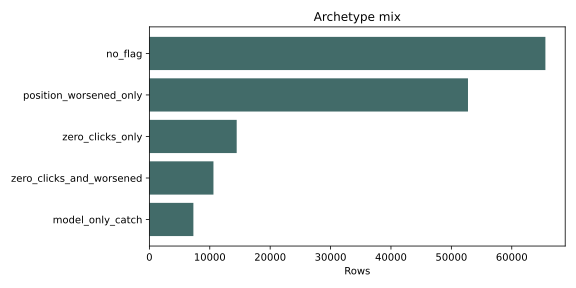

Coverage mix:


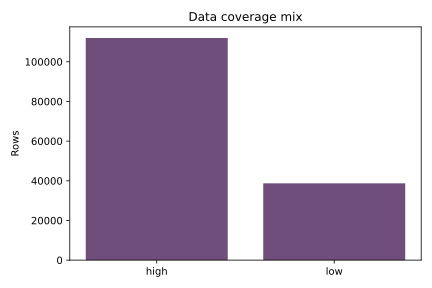

Feature importance:


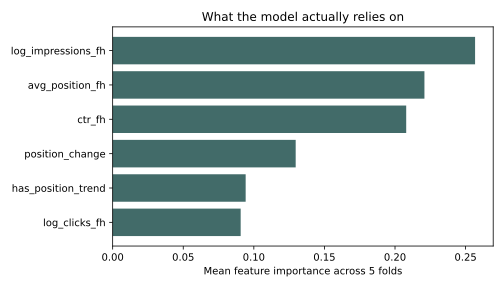

Precision@K:


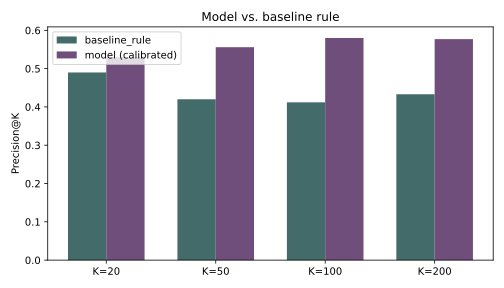

Score distribution by archetype:


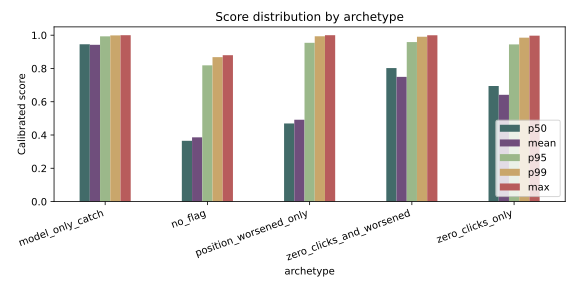

In [13]:
from pathlib import Path
from IPython.display import SVG, display

chart_dir = Path("work/outputs/charts")

for name, title in [
    ("archetype_mix.svg", "Archetype mix"),
    ("coverage_mix.svg", "Coverage mix"),
    ("feature_importance.svg", "Feature importance"),
    ("precision_at_k.svg", "Precision@K"),
    ("score_distribution_by_archetype.svg", "Score distribution by archetype"),
]:
    print(f"{title}:")
    display(SVG(filename=chart_dir / name))

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
